<a href="https://colab.research.google.com/github/efrathshihab/Betel-Leaf-Disease-Prediction/blob/main/MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/Thesis/Betel_Leaf_Resized_2048.zip" -d "/content/"

In [ ]:
!ls "/content/Betel_Leaf_Resized_2048"

Anthracnose  Healthy  Leaf_Curl  Leaf_Rot  Leaf_Spot


In [ ]:
DATA_DIR = "/content/Betel_Leaf_Resized_2048"


In [ ]:
from pathlib import Path

data_dir = Path(DATA_DIR)

for folder in sorted(data_dir.iterdir()):
    if folder.is_dir():
        images = [
            p for p in folder.rglob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ]
        print(folder.name, ":", len(images))

Anthracnose : 980
Healthy : 916
Leaf_Curl : 1120
Leaf_Rot : 963
Leaf_Spot : 1066


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

records = []

for class_dir in sorted(data_dir.iterdir()):
    if class_dir.is_dir():
        for img in class_dir.rglob("*"):
            if img.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                records.append({
                    "filepath": str(img),
                    "label": class_dir.name
                })

df = pd.DataFrame(records)

class_names = sorted(df["label"].unique())
label_to_id = {name: i for i, name in enumerate(class_names)}

df["label_id"] = df["label"].map(label_to_id)

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Classes:", class_names)
print("Total:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Classes: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']
Total: 5045
Train: 4036
Validation: 504
Test: 505


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)

    # Maintain aspect ratio
    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    label = tf.one_hot(label, NUM_CLASSES)

    return image, label


def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label_id"].values
        )
    )

    if training:
        ds = ds.shuffle(
            len(dataframe),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

# Base-paper style normalization
x = layers.Rescaling(1./255)(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

baseline_model = Model(inputs, outputs)

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=32
)

Epoch 1/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 132s 870ms/step - accuracy: 0.7156 - loss: 0.7646 - val_accuracy: 0.8631 - val_loss: 0.4523
Epoch 2/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 75s 587ms/step - accuracy: 0.8657 - loss: 0.4005 - val_accuracy: 0.8948 - val_loss: 0.3542
Epoch 3/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 81s 581ms/step - accuracy: 0.9063 - loss: 0.3096 - val_accuracy: 0.9008 - val_loss: 0.3139
Epoch 4/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 73s 577ms/step - accuracy: 0.9175 - loss: 0.2609 - val_accuracy: 0.9008 - val_loss: 0.2918
Epoch 5/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 76s 595ms/step - accuracy: 0.9277 - loss: 0.2290 - val_accuracy: 0.8948 - val_loss: 0.2760
Epoch 6/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 80s 582ms/step - accuracy: 0.9376 - loss: 0.2086 - val_accuracy: 0.9087 - val_loss: 0.2578
Epoch 7/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 74s 586ms/step - accuracy: 0.9462 - loss: 0.1838 - val_accuracy: 0.9187 - val_loss: 0.2496
Epoch 8/32
127/127 ━━━━━━━━━━━━━━━━━━━━ 81s 575ms/step - accuracy: 0.9504 - loss: 

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="augmentation")


base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


inputs = layers.Input(shape=(224, 224, 3))

x = augmentation(inputs)

# MobileNetV2-specific ImageNet preprocessing
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/Thesis/MobileNetV2_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 88s 603ms/step - accuracy: 0.4586 - loss: 1.3375 - val_accuracy: 0.5575 - val_loss: 1.0333 - learning_rate: 3.0000e-04
Epoch 2/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 78s 611ms/step - accuracy: 0.6440 - loss: 0.8979 - val_accuracy: 0.6687 - val_loss: 0.8160 - learning_rate: 3.0000e-04
Epoch 3/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 610ms/step - accuracy: 0.7324 - loss: 0.7272 - val_accuracy: 0.7163 - val_loss: 0.7190 - learning_rate: 3.0000e-04
Epoch 4/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 80s 596ms/step - accuracy: 0.7765 - loss: 0.6269 - val_accuracy: 0.7103 - val_loss: 0.7036 - learning_rate: 3.0000e-04
Epoch 5/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 78s 612ms/step - accuracy: 0.7939 - loss: 0.5728 - val_accuracy: 0.7480 - val_loss: 0.6295 - learning_rate: 3.0000e-04
Epoch 6/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 80s 597ms/step - accuracy: 0.8102 - loss: 0.5259 - val_accuracy: 0.7956 - val_loss: 0.5376 - learning_rate: 3.0000e-04
Epoch 7/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 80s 58

In [ ]:
base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization frozen
for layer in base_model.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/Thesis/MobileNetV2_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=fine_tune_callbacks
)

Epoch 1/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 86s 625ms/step - accuracy: 0.8793 - loss: 0.3383 - val_accuracy: 0.8452 - val_loss: 0.3972 - learning_rate: 1.0000e-05
Epoch 2/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 77s 603ms/step - accuracy: 0.8942 - loss: 0.2791 - val_accuracy: 0.8452 - val_loss: 0.3943 - learning_rate: 1.0000e-05
Epoch 3/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 603ms/step - accuracy: 0.9081 - loss: 0.2654 - val_accuracy: 0.8214 - val_loss: 0.4337 - learning_rate: 1.0000e-05
Epoch 4/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 83s 617ms/step - accuracy: 0.9185 - loss: 0.2265 - val_accuracy: 0.8591 - val_loss: 0.3851 - learning_rate: 1.0000e-05
Epoch 5/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 75s 593ms/step - accuracy: 0.9180 - loss: 0.2217 - val_accuracy: 0.8849 - val_loss: 0.3011 - learning_rate: 1.0000e-05
Epoch 6/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 85s 616ms/step - accuracy: 0.9279 - loss: 0.2000 - val_accuracy: 0.8988 - val_loss: 0.2723 - learning_rate: 1.0000e-05
Epoch 7/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 78s 58

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 683ms/step - accuracy: 0.8970 - loss: 0.2756
Test Loss: 0.2756447196006775
Test Accuracy: 0.89702969789505


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(y_true, y_pred)

print(cm)

              precision    recall  f1-score   support

 Anthracnose     0.9620    0.7755    0.8588        98
     Healthy     0.9756    0.8791    0.9249        91
   Leaf_Curl     0.9825    1.0000    0.9912       112
    Leaf_Rot     0.8854    0.8763    0.8808        97
   Leaf_Spot     0.7463    0.9346    0.8299       107

    accuracy                         0.8970       505
   macro avg     0.9104    0.8931    0.8971       505
weighted avg     0.9086    0.8970    0.8982       505

[[ 76   1   0   3  18]
 [  3  80   2   1   5]
 [  0   0 112   0   0]
 [  0   1   0  85  11]
 [  0   0   0   7 100]]


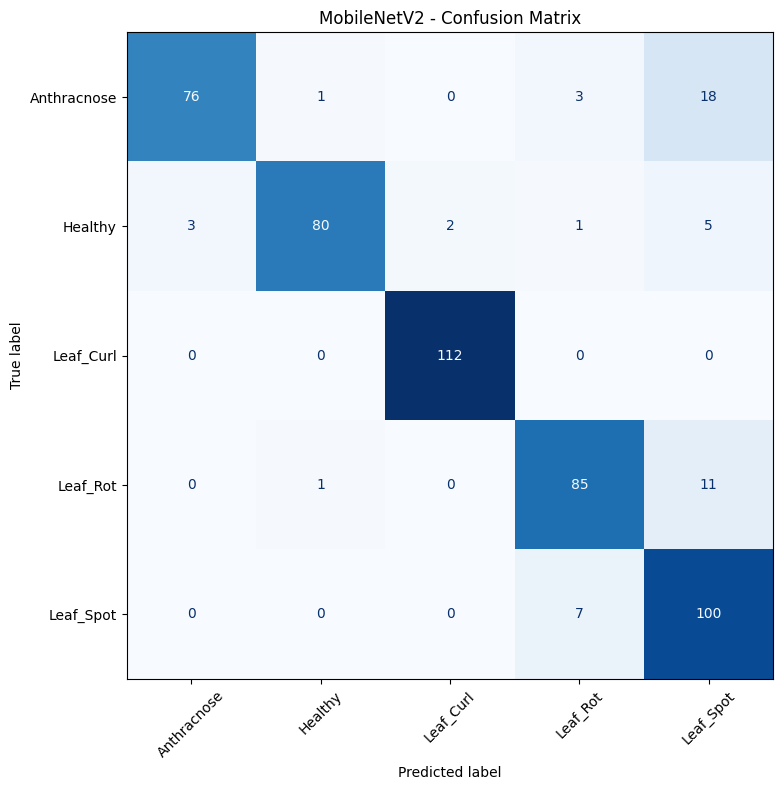

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Test Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision      : {precision * 100:.2f}%")
print(f"Recall         : {recall * 100:.2f}%")
print(f"F1-Score       : {f1 * 100:.2f}%")

Test Accuracy  : 89.70%
Precision      : 90.86%
Recall         : 89.70%
F1-Score       : 89.82%


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Anthracnose,0.962025,0.775510,0.858757,98.00000
Healthy,0.975610,0.879121,0.924855,91.00000
Leaf_Curl,0.982456,1.000000,0.991150,112.00000
Leaf_Rot,0.885417,0.876289,0.880829,97.00000
Leaf_Spot,0.746269,0.934579,0.829876,107.00000
accuracy,0.897030,0.897030,0.897030,0.89703
macro avg,0.910355,0.893100,0.897094,505.00000
weighted avg,0.908575,0.897030,0.898150,505.00000


In [ ]:
report_df.to_csv(
    "/content/drive/MyDrive/Thesis/MobileNetV2_Classification_Report.csv"
)

In [ ]:
model.save(
    "/content/drive/MyDrive/Thesis/MobileNetV2_Improved_Final.keras"
)

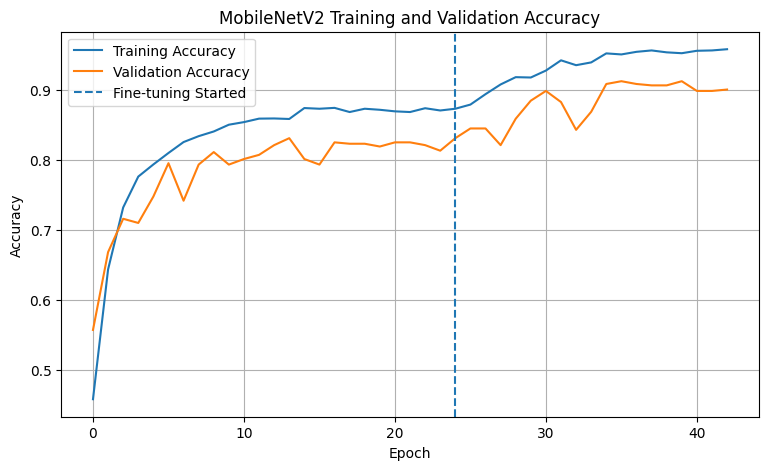

In [ ]:
train_acc = (
    history1.history["accuracy"]
    + history2.history["accuracy"]
)

val_acc = (
    history1.history["val_accuracy"]
    + history2.history["val_accuracy"]
)

plt.figure(figsize=(9, 5))

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.axvline(
    x=len(history1.history["accuracy"]) - 1,
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

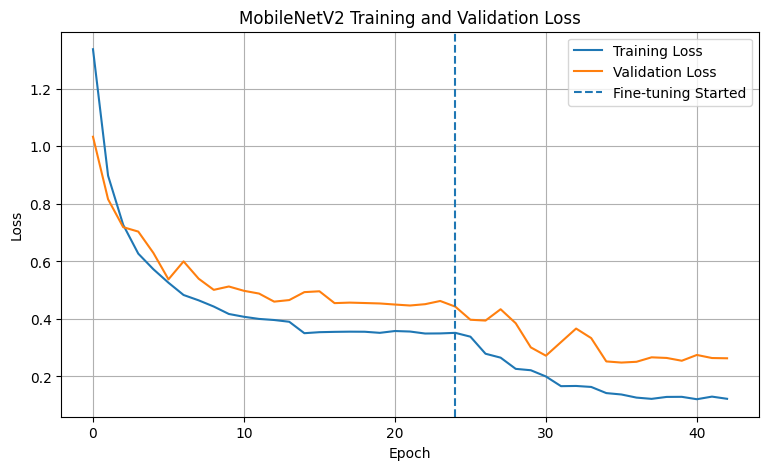

In [ ]:
train_loss = (
    history1.history["loss"]
    + history2.history["loss"]
)

val_loss = (
    history1.history["val_loss"]
    + history2.history["val_loss"]
)

plt.figure(figsize=(9, 5))

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.axvline(
    x=len(history1.history["loss"]) - 1,
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

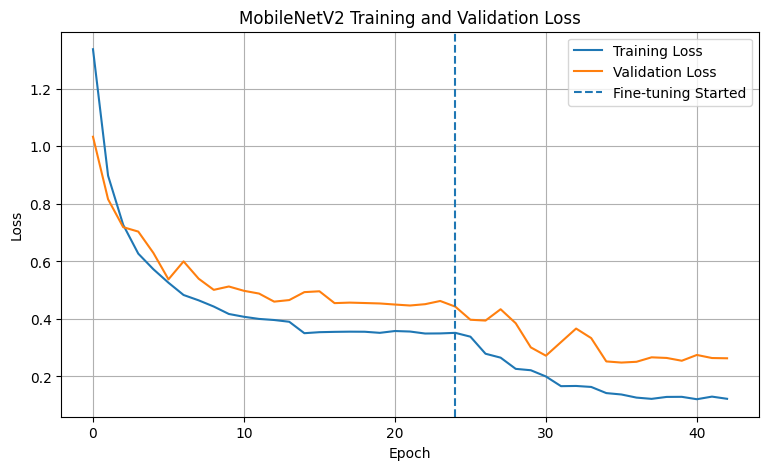

In [ ]:
train_loss = (
    history1.history["loss"]
    + history2.history["loss"]
)

val_loss = (
    history1.history["val_loss"]
    + history2.history["val_loss"]
)

plt.figure(figsize=(9, 5))

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.axvline(
    x=len(history1.history["loss"]) - 1,
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid()

# Save figure
plt.savefig(
    "/content/drive/MyDrive/Thesis/MobileNetV2_Training_Validation_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/Thesis/MobileNetV2_Training_Validation_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/Thesis/MobileNetV2_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

            MOBILENETV2 COMPLETE EXPERIMENT REPORT

[1] EXPERIMENT INFORMATION
----------------------------------------------------------------------
Model Name        : MobileNetV2 Improved
Input Image Size  : 224 x 224 x 3
Batch Size        : 32
Pretrained Weight : ImageNet
Number of Classes : 5
Classes           : Anthracnose, Healthy, Leaf_Curl, Leaf_Rot, Leaf_Spot

[2] DATASET SPLIT
----------------------------------------------------------------------
Total Images      : 5045
Training Images   : 4036
Validation Images : 504
Testing Images    : 505

Training Class Distribution:
label
Anthracnose    784
Healthy        733
Leaf_Curl      896
Leaf_Rot       770
Leaf_Spot      853
Name: count, dtype: int64

Validation Class Distribution:
label
Anthracnose     98
Healthy         92
Leaf_Curl      112
Leaf_Rot        96
Leaf_Spot      106
Name: count, dtype: int64

Testing Class Distribution:
label
Anthracnose     98
Healthy         91
Leaf_Curl      112
Leaf_Rot        97
Leaf_Spot    

,precision,recall,f1-score,support
Anthracnose,0.962025,0.775510,0.858757,98.00000
Healthy,0.975610,0.879121,0.924855,91.00000
Leaf_Curl,0.982456,1.000000,0.991150,112.00000
Leaf_Rot,0.885417,0.876289,0.880829,97.00000
Leaf_Spot,0.746269,0.934579,0.829876,107.00000
accuracy,0.897030,0.897030,0.897030,0.89703
macro avg,0.910355,0.893100,0.897094,505.00000
weighted avg,0.908575,0.897030,0.898150,505.00000



[10] CONFUSION MATRIX
----------------------------------------------------------------------
[[ 76   1   0   3  18]
 [  3  80   2   1   5]
 [  0   0 112   0   0]
 [  0   1   0  85  11]
 [  0   0   0   7 100]]


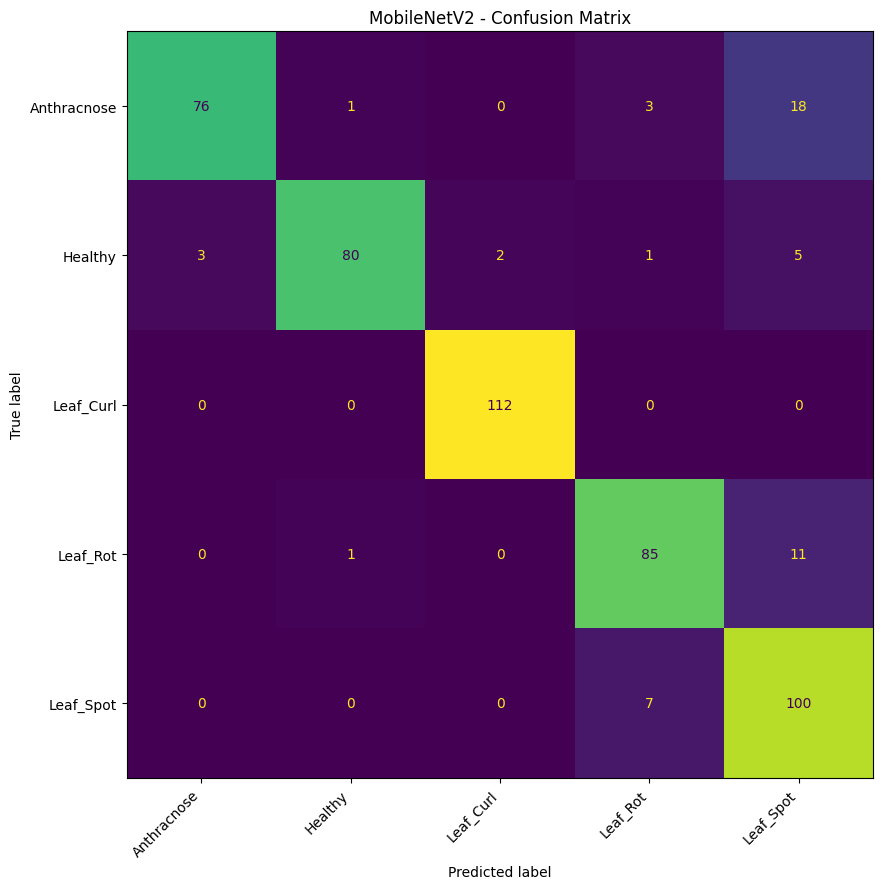

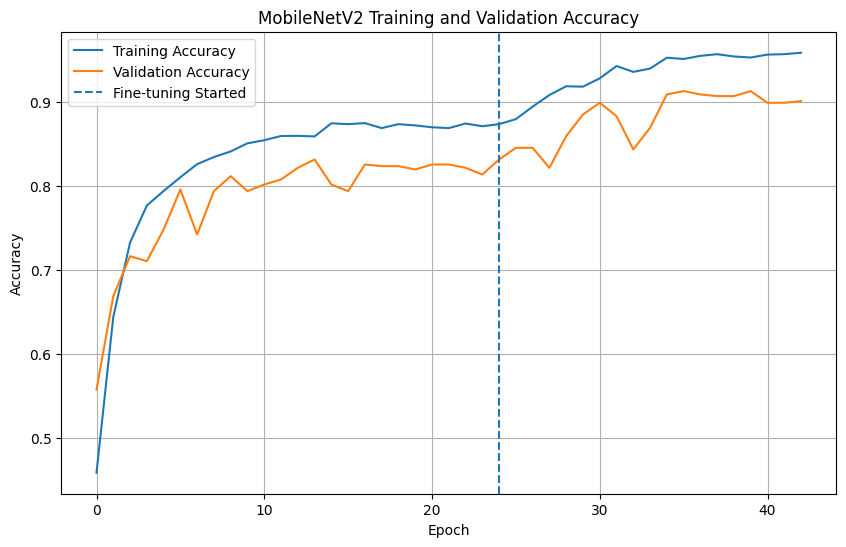

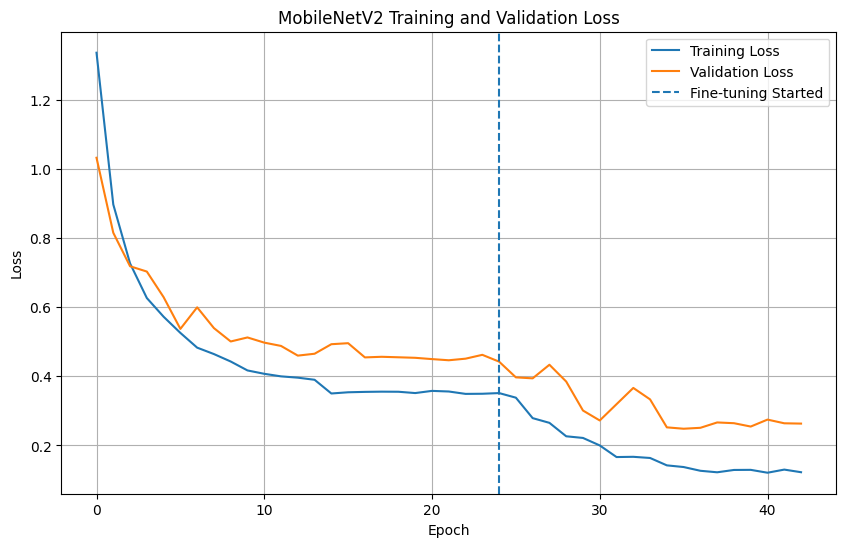


[11] FINAL SUMMARY


,Metric,Result
0,Model,MobileNetV2 Improved
1,Input Size,224 x 224 x 3
2,Total Dataset,5045
3,Training Images,4036
4,Validation Images,504
5,Testing Images,505
6,Total Epochs,43
7,Best Training Accuracy,95.84%
8,Best Validation Accuracy,91.27%
9,Test Accuracy,89.70%



ALL RESULTS SAVED SUCCESSFULLY

Saved Folder:
/content/drive/MyDrive/Thesis/MobileNetV2_Results

Files:
1. MobileNetV2_Final_Summary.csv
2. MobileNetV2_Classification_Report.csv
3. MobileNetV2_Full_Report.txt
4. MobileNetV2_Confusion_Matrix.png
5. MobileNetV2_Training_Validation_Accuracy.png
6. MobileNetV2_Training_Validation_Loss.png


In [ ]:
# ============================================================
# MOBILENETV2 - COMPLETE FINAL EVALUATION REPORT
# ============================================================

import os
import io
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 1. SELECT MODEL
# ============================================================

# Improved/Fine-tuned model
trained_model = model

MODEL_NAME = "MobileNetV2 Improved"
IMAGE_SIZE = "224 x 224 x 3"
BATCH_SIZE = 32

SAVE_DIR = "/content/drive/MyDrive/Thesis/MobileNetV2_Results"
os.makedirs(SAVE_DIR, exist_ok=True)


print("=" * 70)
print("            MOBILENETV2 COMPLETE EXPERIMENT REPORT")
print("=" * 70)


# ============================================================
# 2. BASIC EXPERIMENT INFORMATION
# ============================================================

print("\n[1] EXPERIMENT INFORMATION")
print("-" * 70)

print("Model Name        :", MODEL_NAME)
print("Input Image Size  :", IMAGE_SIZE)
print("Batch Size        :", BATCH_SIZE)
print("Pretrained Weight : ImageNet")
print("Number of Classes :", len(class_names))
print("Classes           :", ", ".join(class_names))


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\n[2] DATASET SPLIT")
print("-" * 70)

print("Total Images      :", len(train_df) + len(val_df) + len(test_df))
print("Training Images   :", len(train_df))
print("Validation Images :", len(val_df))
print("Testing Images    :", len(test_df))


print("\nTraining Class Distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation Class Distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTesting Class Distribution:")
print(test_df["label"].value_counts().sort_index())


# ============================================================
# 4. MODEL INFORMATION
# ============================================================

print("\n[3] MODEL ARCHITECTURE INFORMATION")
print("-" * 70)

total_params = trained_model.count_params()

trainable_params = np.sum([
    np.prod(v.shape)
    for v in trained_model.trainable_weights
])

non_trainable_params = total_params - trainable_params

print("Input Shape              :", trained_model.input_shape)
print("Output Shape             :", trained_model.output_shape)

print(f"Total Parameters         : {total_params:,}")
print(f"Trainable Parameters     : {int(trainable_params):,}")
print(f"Non-Trainable Parameters : {int(non_trainable_params):,}")


# ============================================================
# 5. TRAINING CONFIGURATION
# ============================================================

print("\n[4] TRAINING CONFIGURATION")
print("-" * 70)

print("Optimizer :", trained_model.optimizer.__class__.__name__)
print("Loss      :", trained_model.loss)

try:
    current_lr = float(
        tf.keras.backend.get_value(
            trained_model.optimizer.learning_rate
        )
    )

    print("Current Learning Rate :", current_lr)

except:
    print("Current Learning Rate : Could not retrieve")


# ============================================================
# 6. TRAINING HISTORY
# ============================================================

print("\n[5] TRAINING HISTORY")
print("-" * 70)

# Stage 1
stage1_epochs = len(history1.history["accuracy"])

print("Stage 1 Epochs :", stage1_epochs)

# Stage 2 / Fine-tuning
if "history2" in globals():

    stage2_epochs = len(history2.history["accuracy"])

else:

    stage2_epochs = 0


print("Fine-tuning Epochs :", stage2_epochs)

total_epochs = stage1_epochs + stage2_epochs

print("Total Epochs Actually Trained :", total_epochs)


# Combine both training stages
train_accuracy = history1.history["accuracy"].copy()
val_accuracy = history1.history["val_accuracy"].copy()

train_loss = history1.history["loss"].copy()
val_loss = history1.history["val_loss"].copy()


if "history2" in globals():

    train_accuracy += history2.history["accuracy"]
    val_accuracy += history2.history["val_accuracy"]

    train_loss += history2.history["loss"]
    val_loss += history2.history["val_loss"]


# ============================================================
# 7. BEST TRAINING RESULTS
# ============================================================

best_train_acc = max(train_accuracy)
best_val_acc = max(val_accuracy)

best_train_epoch = np.argmax(train_accuracy) + 1
best_val_epoch = np.argmax(val_accuracy) + 1

lowest_val_loss = min(val_loss)
lowest_val_loss_epoch = np.argmin(val_loss) + 1


print("\n[6] BEST TRAINING PERFORMANCE")
print("-" * 70)

print(
    f"Best Training Accuracy   : "
    f"{best_train_acc * 100:.2f}% "
    f"(Epoch {best_train_epoch})"
)

print(
    f"Best Validation Accuracy : "
    f"{best_val_acc * 100:.2f}% "
    f"(Epoch {best_val_epoch})"
)

print(
    f"Lowest Validation Loss   : "
    f"{lowest_val_loss:.6f} "
    f"(Epoch {lowest_val_loss_epoch})"
)


# ============================================================
# 8. TEST DATASET EVALUATION
# ============================================================

print("\n[7] FINAL TEST EVALUATION")
print("-" * 70)

test_loss, keras_test_accuracy = trained_model.evaluate(
    test_ds,
    verbose=0
)

print(f"Test Loss          : {test_loss:.6f}")
print(f"Keras Test Accuracy: {keras_test_accuracy * 100:.2f}%")


# ============================================================
# 9. GENERATE PREDICTIONS
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = trained_model.predict(
        images,
        verbose=0
    )

    true_labels = np.argmax(
        labels.numpy(),
        axis=1
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)


y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ============================================================
# 10. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n[8] OVERALL TEST METRICS")
print("-" * 70)

print(f"Accuracy             : {accuracy * 100:.2f}%")

print(f"Macro Precision      : {precision_macro * 100:.2f}%")
print(f"Macro Recall         : {recall_macro * 100:.2f}%")
print(f"Macro F1-Score       : {f1_macro * 100:.2f}%")

print(f"Weighted Precision   : {precision_weighted * 100:.2f}%")
print(f"Weighted Recall      : {recall_weighted * 100:.2f}%")
print(f"Weighted F1-Score    : {f1_weighted * 100:.2f}%")


# ============================================================
# 11. CLASS-WISE CLASSIFICATION REPORT
# ============================================================

print("\n[9] CLASS-WISE PERFORMANCE")
print("-" * 70)

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report_text)


report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

print("\nDetailed Classification Table:")
display(report_df)


# ============================================================
# 12. SAVE CLASSIFICATION REPORT
# ============================================================

report_csv_path = os.path.join(
    SAVE_DIR,
    "MobileNetV2_Classification_Report.csv"
)

report_df.to_csv(
    report_csv_path
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n[10] CONFUSION MATRIX")
print("-" * 70)

print(cm)


fig, ax = plt.subplots(
    figsize=(9, 9)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "MobileNetV2 - Confusion Matrix"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

confusion_path = os.path.join(
    SAVE_DIR,
    "MobileNetV2_Confusion_Matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. TRAINING / VALIDATION ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    val_accuracy,
    label="Validation Accuracy"
)

if stage2_epochs > 0:

    plt.axvline(
        x=stage1_epochs - 1,
        linestyle="--",
        label="Fine-tuning Started"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV2 Training and Validation Accuracy"
)

plt.legend()
plt.grid()

accuracy_graph_path = os.path.join(
    SAVE_DIR,
    "MobileNetV2_Training_Validation_Accuracy.png"
)

plt.savefig(
    accuracy_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. TRAINING / VALIDATION LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    train_loss,
    label="Training Loss"
)

plt.plot(
    val_loss,
    label="Validation Loss"
)

if stage2_epochs > 0:

    plt.axvline(
        x=stage1_epochs - 1,
        linestyle="--",
        label="Fine-tuning Started"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MobileNetV2 Training and Validation Loss"
)

plt.legend()
plt.grid()

loss_graph_path = os.path.join(
    SAVE_DIR,
    "MobileNetV2_Training_Validation_Loss.png"
)

plt.savefig(
    loss_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. CREATE SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({

    "Metric": [

        "Model",
        "Input Size",
        "Total Dataset",
        "Training Images",
        "Validation Images",
        "Testing Images",
        "Total Epochs",
        "Best Training Accuracy",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1 Score",
        "Total Parameters",
        "Trainable Parameters",
        "Non-Trainable Parameters"

    ],

    "Result": [

        MODEL_NAME,
        IMAGE_SIZE,
        len(train_df) + len(val_df) + len(test_df),
        len(train_df),
        len(val_df),
        len(test_df),
        total_epochs,
        f"{best_train_acc * 100:.2f}%",
        f"{best_val_acc * 100:.2f}%",
        f"{accuracy * 100:.2f}%",
        f"{precision_macro * 100:.2f}%",
        f"{recall_macro * 100:.2f}%",
        f"{f1_macro * 100:.2f}%",
        f"{precision_weighted * 100:.2f}%",
        f"{recall_weighted * 100:.2f}%",
        f"{f1_weighted * 100:.2f}%",
        f"{total_params:,}",
        f"{int(trainable_params):,}",
        f"{int(non_trainable_params):,}"

    ]

})


print("\n[11] FINAL SUMMARY")
print("=" * 70)

display(summary)


# ============================================================
# 17. SAVE SUMMARY CSV
# ============================================================

summary_csv_path = os.path.join(
    SAVE_DIR,
    "MobileNetV2_Final_Summary.csv"
)

summary.to_csv(
    summary_csv_path,
    index=False
)


# ============================================================
# 18. SAVE FULL TEXT REPORT
# ============================================================

text_report_path = os.path.join(
    SAVE_DIR,
    "MobileNetV2_Full_Report.txt"
)

with open(
    text_report_path,
    "w"
) as f:

    f.write(
        "MOBILENETV2 COMPLETE EXPERIMENT REPORT\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        f"Model: {MODEL_NAME}\n"
    )

    f.write(
        f"Input Size: {IMAGE_SIZE}\n"
    )

    f.write(
        f"Classes: {', '.join(class_names)}\n"
    )

    f.write(
        f"Total Images: "
        f"{len(train_df)+len(val_df)+len(test_df)}\n"
    )

    f.write(
        f"Training Images: {len(train_df)}\n"
    )

    f.write(
        f"Validation Images: {len(val_df)}\n"
    )

    f.write(
        f"Testing Images: {len(test_df)}\n\n"
    )

    f.write(
        f"Best Training Accuracy: "
        f"{best_train_acc * 100:.2f}%\n"
    )

    f.write(
        f"Best Validation Accuracy: "
        f"{best_val_acc * 100:.2f}%\n"
    )

    f.write(
        f"Test Accuracy: "
        f"{accuracy * 100:.2f}%\n\n"
    )

    f.write(
        f"Macro Precision: "
        f"{precision_macro * 100:.2f}%\n"
    )

    f.write(
        f"Macro Recall: "
        f"{recall_macro * 100:.2f}%\n"
    )

    f.write(
        f"Macro F1: "
        f"{f1_macro * 100:.2f}%\n\n"
    )

    f.write(
        "CLASSIFICATION REPORT\n"
    )

    f.write(
        "-" * 60 + "\n"
    )

    f.write(
        report_text
    )


print("\n" + "=" * 70)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("=" * 70)

print("\nSaved Folder:")
print(SAVE_DIR)

print("\nFiles:")
print("1. MobileNetV2_Final_Summary.csv")
print("2. MobileNetV2_Classification_Report.csv")
print("3. MobileNetV2_Full_Report.txt")
print("4. MobileNetV2_Confusion_Matrix.png")
print("5. MobileNetV2_Training_Validation_Accuracy.png")
print("6. MobileNetV2_Training_Validation_Loss.png")

In [ ]:
!git clone https://github.com/efrathshihab/Betel-Leaf-Disease-Prediction.git

Cloning into 'Betel-Leaf-Disease-Prediction'...
fatal: could not read Username for 'https://github.com': No such device or address
